In [1]:
import os
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio import windows
from pathlib import Path
import matplotlib.pyplot as plt

from tqdm import tqdm

# SET ENV VARIABLES

In [2]:
DATA_DIR = Path("D:/PHD/HSI_DOWNSTREAM_DATASETS/emit_ch4")
MASK_DIR = DATA_DIR / "plumes_masks"
IMG_DIR  = DATA_DIR / "EMIT_L2A" 

SAMPLE_NAMES = [name.name for name in MASK_DIR.glob("*.tif")]

METADATA_CSV = r"C:\Users\Julia\OneDrive\Dokumenty\WORK\PhD\IBM\CH4\metadata_master_manifest.csv"

In [3]:
manifest_df = pd.read_csv(METADATA_CSV)
acronym_dict = dict(zip(manifest_df['name'], manifest_df['acronym']))

# CROP

### Define helper functions

In [3]:
def _validate_pair(
    mask: rio.DatasetReader, 
    img: rio.DatasetReader, 
    mask_path: Path, 
    img_path: Path
) -> None:
    """Raise ValueError if mask and image are spatially inconsistent."""
    if mask.crs != img.crs:
        raise ValueError(
            f"CRS mismatch: {mask_path.name} has {mask.crs}, "
            f"{img_path.name} has {img.crs}"
        )
    if (mask.width, mask.height) != (img.width, img.height):
        raise ValueError(
            f"Size mismatch: mask is {mask.width}x{mask.height}, "
            f"image is {img.width}x{img.height} — {mask_path.name}"
        )
        
    # Transforms should agree to within floating-point tolerance
    if not _transforms_close(mask.transform, img.transform):
        raise ValueError(
            f"Transform mismatch between {mask_path.name} and {img_path.name}:\n"
            f"  mask : {mask.transform}\n"
            f"  image: {img.transform}"
        )
        
def _transforms_close(t1: rio.Affine, t2: rio.Affine, tol: float = 1e-6) -> bool:
    """Return True if two affine transforms are element-wise within `tol`."""
    return all(abs(a - b) < tol for a, b in zip(t1, t2))


def _choose_window(mask: rio.DatasetReader, w_out: int, h_out: int) -> windows.Window | None:
    """Decide which crop window to use for a wxh tile.

    Args:
        mask (rio.DatasetReader): the CH4 annotation.
        w_out (int): Output width.
        h_out (int): Output height.

    Returns:
        Window((w - w_out)//2, (h - h_out)//2, (w - w_out)//2 + w_out, (h - h_out)//2 + h_out) if the contour ring is empty.
        Window(0,   0,   w, h) if the contour ring has annotations.
        None if the tile has no annotations at all (no-op).
    """
    full   = mask.read(1) 
    h, w   = full.shape 
    center = full[(h - h_out)//2:(h + h_out)//2, (w - w_out)//2:(w + w_out)//2]  # numpy slice — no extra I/O

    contour_sum = full.sum() - center.sum()
                    
    if contour_sum == 0:
        return windows.Window(col_off=(w - w_out)//2, row_off=(h - h_out)//2, width=w_out, height=h_out)

    return None # No cropping, keep full window

def _build_profile(
    src: rio.DatasetReader,
    data: np.ndarray,
    window: windows.Window
) -> dict:
    """Build a rasterio write profile for a cropped window."""
    profile = src.profile.copy()
    profile.update({
        'height':    window.height,
        'width':     window.width,
        'transform': src.window_transform(window),
        'dtype':     data.dtype,
        'count':     src.count,
        'compress':  'lzw',
    })
    
    return profile

## Main cropping logic

In [ ]:
def check_and_crop(mask_path: Path, img_path: Path, w: int, h: int, out_w: int, out_h: int) -> bool:
    """
    Opens the CH4 annotation tile, checks if the file is wxh and if the contour
    is empty. Crops the empty-contour images and masks, replacing the originals.

    For wxh tiles:
      - contour_sum == 0 → crop to the (w//2)x(h//2) center window
      - contour_sum  > 0 → leave as is (full window)
    Args:
        mask_path: Path to the binary CH4 annotation mask (.tif)
        img_path:  Path to the corresponding EMIT HSI tile (.tif)
        w: Width of the tile
        h: Height of the tile
        out_w: Output width of the cropped window
        out_h: Output height of the cropped window
        tracker: A counter for tracking processed files

    Raises:
        ValueError: If mask/image spatial metadata are inconsistent.
        RuntimeError: If an unexpected tile shape is encountered.
    """

    temp_mask_path = mask_path.with_name(f".temp_{mask_path.name}")
    temp_img_path = img_path.with_name(f".temp_{img_path.name}")
    
    try:            
        with rio.open(mask_path) as mask, rio.open(img_path) as img:
            if mask.width != w or mask.height != h:
                return False
               
            _validate_pair(mask, img, mask_path, img_path)

            crop_window = _choose_window(mask, w_out=out_w, h_out=out_h) 
                         
            if crop_window is None:
                return False  # No cropping needed, keep original files
                            
            mask_data = mask.read(window=crop_window)
            img_data  = img.read(window=crop_window)
            
            mask_kwargs = _build_profile(mask, mask_data, crop_window)
            img_kwargs  = _build_profile(img,  img_data,  crop_window)
            
                    
        with rio.open(temp_mask_path, 'w', **mask_kwargs) as dst_mask:
            dst_mask.write(mask_data)
                    
        with rio.open(temp_img_path, 'w', **img_kwargs) as dst_img:
            dst_img.write(img_data)
                                    
        os.replace(temp_mask_path, mask_path)
        os.replace(temp_img_path, img_path)
        
        return True  # Cropping was performed
                
    except Exception:
        for p in (temp_mask_path, temp_img_path):
            p.unlink(missing_ok=True)
        raise

In [ ]:
cropped_count = 0
for filename in tqdm(SAMPLE_NAMES):
    mask_path = MASK_DIR / filename
    img_path  = IMG_DIR  / filename
    
    was_cropped = check_and_crop(
        mask_path=mask_path, 
        img_path=img_path, 
        w=256, h=256, 
        out_w=128, out_h=128
    )
    
    if was_cropped:
        cropped_count += 1

print(f"Done. {cropped_count} files were cropped.")

  0%|          | 0/1575 [00:00<?, ?it/s]

100%|██████████| 1575/1575 [1:08:31<00:00,  2.61s/it]

Done. 1090 files were cropped.


### Post crop analysis

In [ ]:
i = 0
for filename in tqdm(SAMPLE_NAMES):
    mask_path = MASK_DIR / filename
    with rio.open(mask_path) as mask:
        if mask.width == 512 and mask.height == 512:
            i += 1 
print(f"{i} 512x512.")

100%|██████████| 1574/1574 [00:08<00:00, 182.27it/s]

75 512x512.


In [ ]:
est_no_tiles  = 1270+189*4+75*16+408
est_positives = 2725
est_negatives = 909

print(f"Estimated total number of 128x128 tiles in the training set: {est_no_tiles}.")
print(f"Of which {est_positives} positive, and {est_negatives} negatives. Giving a 3:1 pos:neg ratio. (FOR NOW)")

Estimated total number of 128x128 tiles in the training set: 3634.
Of which 2725 positive, and 909 negatives. Giving a 3:1 pos:neg ratio. (FOR NOW)


# TILE

In [ ]:
def tile_and_delete_parent(mask_path: Path, img_path: Path, tile_dim: int = 128) -> bool:
    """
    Slices a parent scene into non-overlapping 128x128 chips.
    Saves them in the same directory, then deletes the original parent file.
    """
    scene_id = mask_path.stem 
    acronym = acronym_dict.get(scene_id, "GLOBAL")
    
    # Open context manager to read data
    with rio.open(mask_path) as mask_src, rio.open(img_path) as img_src:
        h, w = mask_src.height, mask_src.width
        
        if h == 128 and w == 128:
            mask_full = mask_src.read(1)
            has_methane = 1 if np.any(mask_full > 0) else 0
            standard_name = f"{scene_id}_{acronym}_{has_methane}_r00_c00.tif"
            mask_src.close()
            img_src.close()
            os.rename(mask_path, mask_path.with_name(standard_name))
            os.rename(img_path, img_path.with_name(standard_name))
            return True
        
        if h not in [256, 512] or w not in [256, 512]:    
            return False
            
        _validate_pair(mask_src, img_src, mask_path, img_path)
        
        rows = h // tile_dim
        cols = w // tile_dim
        
        # Temporary storage to hold tile arrays and headers in memory
        tile_queue = []
        
        for r in range(rows):
            for c in range(cols):
                window = windows.Window(
                    col_off  = c * tile_dim, 
                    row_off  = r * tile_dim, 
                    width    = tile_dim, 
                    height   = tile_dim
                )
                
                mask_data    = mask_src.read(1, window=window)
                img_data     = img_src.read(window=window)
                has_methane  = 1 if np.any(mask_data > 0) else 0
                
                tile_name    = f"{scene_id}_{acronym}_{has_methane}_r{r:02d}_c{c:02d}.tif"
                
                mask_profile = _build_profile(mask_src, mask_data[np.newaxis, ...], window)
                img_profile  = _build_profile(img_src, img_data, window)
                
                # Queue it up to write after the main file closes safely
                tile_queue.append((tile_name, mask_data, img_data, mask_profile, img_profile))


    for tile_name, m_data, i_data, m_prof, i_prof in tile_queue:
        out_mask = MASK_DIR / tile_name
        out_img = IMG_DIR / tile_name
        
        with rio.open(out_mask, 'w', **m_prof) as dst:
            dst.write(m_data, 1)
        with rio.open(out_img, 'w', **i_prof) as dst:
            dst.write(i_data)

    mask_path.unlink()
    img_path.unlink()
    
    return True

In [ ]:
all_scenes = [p for p in MASK_DIR.glob("*.tif") if not any(p.name.startswith(acr + "_") for acr in acronym_dict.values())]
    
print(f"Found {len(all_scenes)} original files to process in-place...")
    
success_count = 0
for mask_path in tqdm(all_scenes):
    img_path = IMG_DIR / mask_path.name
        
    if not img_path.exists():
        continue
            
    try:
        if tile_and_delete_parent(mask_path, img_path):
            success_count += 1
            
    except Exception as e:
        print(f"\nError processing {mask_path.name}: {str(e)}")
        continue

print(f"\nOperation Complete. Successfully processed/converted {success_count} parent files into clean 128x128 slices.")

Found 1574 original files to process in-place...


100%|██████████| 1574/1574 [39:10<00:00,  1.49s/it]  


Operation Complete. Successfully processed/converted 1534 parent files into clean 128x128 slices.


## TILE IRREGULARS

In [5]:
import math

def tile_irregular_tif_dynamic_overlap(mask_path: Path, img_path: Path, tile_dim: int = 128) -> bool:
    """
    Tiles an irregular large TIF using a sliding window with dynamically calculated 
    overlap so that no pixels are discarded and windows are evenly spaced.
    """
    scene_id = mask_path.stem
    acronym = acronym_dict.get(scene_id, "GLOBAL")
    
    with rio.open(mask_path) as mask_src, rio.open(img_path) as img_src:
        raw_h, raw_w = mask_src.height, mask_src.width
        
        if raw_h == 128 and raw_w == 128:
            return False 
            
        # 1. CALCULATE HOW MANY TILES WE NEED TO COVER THE SPACE (ROUND UP)
        cols = math.ceil(raw_w / tile_dim)
        rows = math.ceil(raw_h / tile_dim)
        
        # 2. GENERATE EQUALLY SPACED STARTING PIXEL COORDINATES
        # If raw_w == tile_dim, it just generates [0]
        if raw_w > tile_dim:
            col_offsets = np.linspace(0, raw_w - tile_dim, cols, dtype=int)
        else:
            col_offsets = [0]
            cols = 1
            
        if raw_h > tile_dim:
            row_offsets = np.linspace(0, raw_h - tile_dim, rows, dtype=int)
        else:
            row_offsets = [0]
            rows = 1
            
        # Extract profiles and arrays into RAM
        mask_profile = mask_src.profile.copy()
        img_profile = img_src.profile.copy()
        
        mask_transform = mask_src.transform
        img_transform = img_src.transform
        
        full_mask = mask_src.read(1)
        full_img = img_src.read()

    # Parents closed safely.
    
    # 3. SLIDING WINDOW GRID USING THE DYNAMIC OFFSETS
    for r_idx, r_start in enumerate(row_offsets):
        for c_idx, c_start in enumerate(col_offsets):
            r_end = r_start + tile_dim
            c_end = c_start + tile_dim
            
            # Slice numpy array in RAM instantly
            mask_slice = full_mask[r_start:r_end, c_start:c_end]
            img_slice = full_img[:, r_start:r_end, c_start:c_end]
            
            has_methane = 1 if np.any(mask_slice > 0) else 0
            
            # Using r_idx and c_idx for clean grid numbering (00, 01, 02...)
            tile_name = f"{scene_id}_{acronym}_{has_methane}_r{r_idx:02d}_c{c_idx:02d}.tif"
            
            # Reconstruct the window context to translate geospatial metadata bounds
            window = windows.Window(col_off=c_start, row_off=r_start, width=tile_dim, height=tile_dim)
            out_mask_transform = rio.windows.transform(window, mask_transform)
            out_img_transform = rio.windows.transform(window, img_transform)
            
            m_prof = mask_profile.copy()
            m_prof.update({'height': tile_dim, 'width': tile_dim, 'transform': out_mask_transform, 'count': 1, 'compress': 'lzw'})
            
            i_prof = img_profile.copy()
            i_prof.update({'height': tile_dim, 'width': tile_dim, 'transform': out_img_transform, 'count': img_slice.shape[0], 'compress': 'lzw'})
            
            # 4. STREAM OUT TO STORAGE
            with rio.open(MASK_DIR / tile_name, 'w', **m_prof) as dst:
                dst.write(mask_slice, 1)
            with rio.open(IMG_DIR / tile_name, 'w', **i_prof) as dst:
                dst.write(img_slice)
                
    # 5. PURGE THE OLD LARGE FILE
    mask_path.unlink()
    img_path.unlink()
    
    return True

In [1]:
all_scenes = [p for p in MASK_DIR.glob("*.tif") if not any(p.name.startswith(acr + "_") for acr in acronym_dict.values())]
    
print(f"Found {len(all_scenes)} original files to process in-place...")
    
success_count = 0
for mask_path in tqdm(all_scenes):
    img_path = IMG_DIR / mask_path.name
        
    if not img_path.exists():
        continue
            
    try:
        if tile_irregular_tif_dynamic_overlap(mask_path, img_path):
            success_count += 1
            
    except Exception as e:
        print(f"\nError processing {mask_path.name}: {str(e)}")
        continue

print(f"\nOperation Complete. Successfully processed/converted {success_count} parent files into clean 128x128 slices.")

NameError: name 'MASK_DIR' is not defined

# Qua-qua-quaabity... no, but I'm getting close
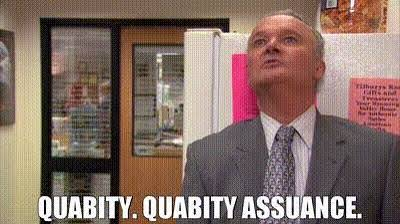

## irregular plumes cleanup

In [4]:
irregular_plumes = pd.read_csv("C:\\Users\\Julia\\OneDrive\\Dokumenty\\WORK\\PhD\\IBM\\CH4\\irregular_plumes.csv")
irregular_plumes.head()

,name,latitude (centroid),longitude (centroid),area_km2,bounds,width_km,height_km,startDate,endDate,max_ch4_concentration,concentration_uncertainty,geometry
0,20220815T042826_000492,39.499838,53.511442,253.332528,"(53.2865403, 39.4400431, 53.8282305, 39.5604187)",46.592402,13.364706,2022-08-15T04:28:26Z,2022-08-15T04:28:26Z,4626.0,422.0,"POLYGON ((53.3315456 39.5604187, 53.3076873 39..."
1,20220815T042826_000493,39.383045,53.615972,170.886093,"(53.418845, 39.3500325, 53.8477509, 39.4264873)",36.950629,8.488234,2022-08-15T04:28:26Z,2022-08-15T04:28:26Z,4694.0,313.0,"POLYGON ((53.4378231 39.4264873, 53.4286052 39..."
2,20220820T083324_000513,40.117429,60.740075,236.076766,"(60.631622, 40.0099295, 60.8533951, 40.239836)",18.903511,25.528136,2022-08-20T08:33:24Z,2022-08-20T08:33:24Z,1494.0,298.0,"POLYGON ((60.7536243 40.239836, 60.7519976 40...."
3,20220827T060753_000538,36.416637,61.732207,205.453630,"(61.6049294, 36.3563667, 61.8971927, 36.5304234)",26.203227,19.314592,2022-08-27T06:06:54Z,2022-08-27T06:06:54Z,8691.0,340.0,"POLYGON ((61.6629482 36.5304234, 61.6607793 36..."
4,20220828T051941_000921,38.632177,64.537106,143.836458,"(64.4212851, 38.4889672, 64.6522761, 38.8045466)",20.109027,35.032075,2022-08-28T05:18:53Z,2022-08-28T05:18:53Z,6397.0,244.0,"POLYGON ((64.6479383 38.8045466, 64.6392625 38..."


In [9]:
invalid_imgs = []
for plume in irregular_plumes["name"].unique():
    mask_paths = list(MASK_DIR.glob(f"{plume}_*.tif"))
    img_paths = list(IMG_DIR.glob(f"{plume}_*.tif"))
    
    # check if the HSI tiles are valid (if more than 20% of a single tile contains 0s across all bands the tile is invalid and needs to be masked as such and removed from the training set)
    for image_path in img_paths:
        with rio.open(image_path) as src:
            img_data = src.read()
            total_pixels = img_data.size
            zero_pixels = np.sum(img_data == 0)
            zero_ratio = zero_pixels / total_pixels
            
            if zero_ratio > 0 and zero_ratio < 0.2:
                print(f"Tile {image_path.name} is invalid (zero ratio: {zero_ratio:.2f}). Consider masking or removing it from the training set.")
                invalid_imgs.append(image_path.name)

Tile 20220815T042826_000492_ST_1_r00_c00.tif is invalid (zero ratio: 0.08). Consider masking or removing it from the training set.
Tile 20220820T083324_000513_ST_1_r00_c01.tif is invalid (zero ratio: 0.07). Consider masking or removing it from the training set.
Tile 20220820T083324_000513_ST_1_r01_c02.tif is invalid (zero ratio: 0.03). Consider masking or removing it from the training set.
Tile 20230131T053936_000601_AS_1_r01_c00.tif is invalid (zero ratio: 0.00). Consider masking or removing it from the training set.
Tile 20230223T063033_000710_ST_1_r00_c01.tif is invalid (zero ratio: 0.00). Consider masking or removing it from the training set.
Tile 20230425T051216_000860_CM_1_r04_c00.tif is invalid (zero ratio: 0.03). Consider masking or removing it from the training set.
Tile 20230426T055703_000874_ST_1_r01_c00.tif is invalid (zero ratio: 0.03). Consider masking or removing it from the training set.
Tile 20230429T050823_000894_ST_1_r00_c04.tif is invalid (zero ratio: 0.07). Conside

In [ ]:
unnecessary_files_manual = [
    "20220815T042826_000492_ST_1_r00_c00.tif",
    "20220820T083324_000513_ST_1_r00_c01.tif",
    "20220820T083324_000513_ST_1_r01_c02.tif",
    "20230223T063033_000710_ST_1_r00_c01.tif",
    "20230429T050823_000894_ST_1_r00_c04.tif",
    "20230429T050823_000894_ST_1_r00_c03.tif",
    "20231003T074704_001596_ST_1_r01_c00.tif",
    "20231124T142642_001959_SA_1_r01_c00.tif",
    "20240405T170129_002977_AM_1_r03_c01.tif",
    "20240405T170129_002977_AM_1_r02_c00.tif",
    "20240421T184222_003061_AM_1_r00_c00.tif",
    "20240619T050711_003329_EU_1_r01_c03.tif",
    "20220820T083324_000513_ST_1_r00_c02.tif",
    "20231204T100051_002015_ME_1_r00_c00.tif",
    "20231003T074704_001596_ST_1_r00_c00.tif",
    "20231009T060956_002607_ST_1_r00_c00.tif",
    "20231124T142642_001959_SA_1_r00_c00.tif",
    "20231204T100051_002015_ME_1_r01_c00.tif",
    "20240405T170129_002977_AM_0_r03_c00.tif",
    "20240405T170129_002977_AM_0_r04_c01.tif",
    "20240405T170129_002977_AM_0_r05_c02.tif",
    "20240405T170129_002977_AM_0_r06_c03.tif",
    "20230131T053936_000601_AS_0_r00_c00.tif",
    "20240421T184222_003061_AM_1_r01_c00.tif",
    "20240421T184222_003061_AM_0_r02_c00.tif",
    "20240421T184222_003061_AM_1_r02_c01.tif",
    "20240823T173814_003469_AM_1_r05_c06.tif",
    "20240823T173814_003469_AM_1_r00_c00.tif",
    "20240823T173814_003469_AM_1_r00_c01.tif",
    "20240823T173814_003469_AM_1_r00_c02.tif",
    "20240823T173814_003469_AM_1_r00_c03.tif",
    "20240823T173814_003469_AM_0_r00_c04.tif",
    "20240823T173814_003469_AM_0_r00_c05.tif",
    "20240823T173814_003469_AM_0_r00_c06.tif",
    "20240823T173814_003469_AM_0_r00_c07.tif",
    "20240823T173814_003469_AM_0_r00_c08.tif",
    "20240823T173814_003469_AM_0_r00_c09.tif",
    "20240823T173814_003469_AM_1_r01_c00.tif",
    "20240823T173814_003469_AM_1_r01_c01.tif",
    "20240823T173814_003469_AM_1_r01_c02.tif",
    "20240823T173814_003469_AM_1_r01_c03.tif",
    "20240823T173814_003469_AM_1_r01_c04.tif",
    "20240823T173814_003469_AM_0_r01_c05.tif",
    "20240823T173814_003469_AM_0_r01_c06.tif",
    "20240823T173814_003469_AM_0_r01_c07.tif",
    "20240823T173814_003469_AM_0_r01_c08.tif",
    "20240823T173814_003469_AM_0_r01_c09.tif",
    "20240823T173814_003469_AM_1_r02_c06.tif",
    "20240823T173814_003469_AM_0_r02_c07.tif",
    "20240823T173814_003469_AM_0_r02_c08.tif",
    "20240823T173814_003469_AM_0_r02_c09.tif",
    "20240823T173814_003469_AM_0_r03_c00.tif",
    "20240823T173814_003469_AM_0_r03_c01.tif",
    "20240823T173814_003469_AM_0_r03_c02.tif",
    "20240823T173814_003469_AM_1_r03_c04.tif",
    "20240823T173814_003469_AM_1_r03_c07.tif",
    "20240823T173814_003469_AM_0_r03_c08.tif",
    "20240823T173814_003469_AM_0_r03_c09.tif",
    "20240823T173814_003469_AM_0_r04_c00.tif",
    "20240823T173814_003469_AM_0_r04_c01.tif",
    "20240823T173814_003469_AM_0_r04_c02.tif",
    "20240823T173814_003469_AM_0_r04_c03.tif",
    "20240823T173814_003469_AM_1_r04_c05.tif",
    "20240823T173814_003469_AM_1_r04_c09.tif",
]

for filename in unnecessary_files_manual:
    mask_file = MASK_DIR / filename
    img_file = IMG_DIR / filename
    
    if mask_file.exists():
        mask_file.unlink()
    if img_file.exists():
        img_file.unlink()

64

## invalid pixels masking

In [4]:
def clean_invalid_pixels(mask_path: Path, img_path: Path) -> bool:
    """
    Cleans a single 128x128 tile pair in place:
    1. Replaces image NaNs/dropouts with 0.0
    2. Replaces corresponding mask labels with -1 (ignore index).
    """
    with rio.open(mask_path) as mask_src, rio.open(img_path) as img_src:
        mask_profile = mask_src.profile.copy()
        img_profile  = img_src.profile.copy()
        
        img_data     = img_src.read()
        mask_data    = mask_src.read(1).astype(np.int8)
        
    nan_mask         = np.any(np.isnan(img_data), axis=0)
    is_all_zero      = (img_data == 0).all(axis=0)
    invalid_pixels   = nan_mask | is_all_zero
    
    if not np.any(invalid_pixels):
        return False # No invalid pixels, skip
    
    if np.all(invalid_pixels):
        print(f"Warning: All pixels in {img_path.name} are invalid. Consider removing this tile.")
        return False
    
    np.nan_to_num(img_data, nan=0.0, copy=False)  # Replace NaNs with 0.0 in-place
    
    img_data[:, invalid_pixels] = 0.0  # Set all bands to 0 where invalid
    mask_data[invalid_pixels]   = -1   # Set to ignore index
    
    mask_profile.update({'dtype': 'int8', 'compress': 'lzw'})
    img_profile.update({'compress': 'lzw'})
    
    with rio.open(mask_path, 'w', **mask_profile) as dst_m:
        dst_m.write(mask_data, 1)
        
    with rio.open(img_path, 'w', **img_profile) as dst_i:
        dst_i.write(img_data)
        
    return True
    

In [14]:
modified_count = 0
for filename in tqdm(SAMPLE_NAMES[3765:]):
    mask_file = MASK_DIR / filename
    img_file = IMG_DIR / filename
    
    if clean_invalid_pixels(mask_file, img_file):
        modified_count += 1

print(f"Done. Cleaned {modified_count} tiles with invalid pixels.")

100%|██████████| 106/106 [01:15<00:00,  1.40it/s]

Done. Cleaned 14 tiles with invalid pixels.


## final invalid tiles cleanup

In [41]:
invalid_tiles_total = {"20220829T060913_000544_AS_0_r02_c00.tif": 1.0,
                 "20220829T060913_000544_AS_0_r03_c00.tif": 1.0,
                 "20220829T060913_000544_AS_0_r03_c01.tif": 1.0,
                 "20230417T095836_000814_ST_0_r03_c00.tif": 1.0,
                 "20230417T095836_000814_ST_0_r03_c01.tif": 1.0,
                 "20230601T093903_002216_ST_0_r03_c03.tif": 1.0,
                 "20230610T053019_000941_ME_0_r03_c03.tif": 1.0,
                 "20230816T101050_001551_ST_0_r00_c00.tif": 1.0,
                 "20230825T170609_001111_AM_0_r03_c00.tif": 1.0,
                 "20230828T070310_001204_ME_0_r00_c03.tif": 1.0,
                 "20230828T070310_001204_ME_0_r02_c03.tif": 1.0,
                 "20230828T070310_001204_ME_0_r03_c02.tif": 1.0,
                 "20230828T070310_001204_ME_0_r03_c03.tif": 1.0,
                 "20230828T083409_001201_ME_0_r00_c03.tif": 1.0,
                 "20231008T051536_001633_ME_0_r03_c03.tif": 1.0,
                 "20231023T075004_001844_ME_0_r00_c03.tif": 1.0,
                 "20240214T105733_002690_ME_0_r00_c03.tif": 1.0,
                 "20240419T092534_003193_ME_0_r00_c02.tif": 1.0,
                 "20240419T092534_003193_ME_0_r00_c03.tif": 1.0,
                 "20240419T092534_003193_ME_0_r01_c03.tif": 1.0,
                 "20240701T162527_003313_SA_0_r00_c03.tif": 1.0,
                 "20240728T095246_003384_ST_0_r00_c00.tif": 1.0}

In [42]:
invalid_tiles = {}
for filename in tqdm(SAMPLE_NAMES):
    mask_file = MASK_DIR / filename
    img_file = IMG_DIR / filename
    
    with rio.open(mask_file) as src:
        mask_data = src.read()
        total_pixels = mask_data.size
        invalid_pixels = np.sum(mask_data == -1)
        zero_ratio = invalid_pixels / total_pixels
            
        if zero_ratio > 0:
            invalid_tiles[filename] = zero_ratio

100%|██████████| 3871/3871 [00:36<00:00, 105.27it/s]


In [43]:
invalid_tiles_filtered = {k: v for k, v in invalid_tiles.items() if v > 0.5}

In [45]:
tiles_to_eliminate = list(invalid_tiles_filtered.keys())
tiles_to_eliminate.extend(list(invalid_tiles_total.keys()))

len(tiles_to_eliminate)

80

In [46]:
for filename in tiles_to_eliminate:
    mask_file = MASK_DIR / filename
    img_file = IMG_DIR / filename
    
    if mask_file.exists():
        mask_file.unlink()
    if img_file.exists():
        img_file.unlink()

## border plume tiles

In [7]:
SAMPLE_NAMES[0].split('_')[3]

'1'

In [10]:
bin_0 = 0
bin_1 = 0
bin_2 = 0
bin_3 = 0
bin_4 = 0

for file in tqdm(SAMPLE_NAMES):
    mask_file = MASK_DIR / file
    methane_flag = file.split("_")[3]
    
    if not mask_file.exists():
        print(f"Missing mask for {file}: {mask_file.exists()}")

    if methane_flag == "0":
        bin_0 += 1
        
    if methane_flag == "1":
        with rio.open(mask_file) as src:
            mask_data = src.read(1)
            
            plume = np.sum(mask_data == 1)
            background = np.sum(mask_data == 0)
            ignore = np.sum(mask_data == -1)
            if background == 0:
                ratio = 1
            else:               
                ratio = plume/background
            
            if ratio < 0.01:
                bin_1 += 1
                
            elif ratio >= 0.01 and ratio < 0.1:
                bin_2 += 1
            
            elif ratio >= 0.1 and ratio < 0.5:
                bin_3 += 1
            
            else:
                bin_4 += 1

print(f"background tiles: {bin_0}\n sparse methane (<1%): {bin_1}\n small plumes/parts (1-10%): {bin_2}\n normal plumes (10-50%): {bin_3}\n big plumes (50-100%): {bin_4}")
            

100%|██████████| 3791/3791 [01:15<00:00, 49.93it/s] 

background tiles: 845
 sparse methane (<1%): 212
 small plumes/parts (1-10%): 1262
 normal plumes (10-50%): 1025
 big plumes (50-100%): 447


# Organizing the dataset

In [47]:
acronym_to_split = {
    "AM" : "train",
    "ST" : "train",
    "ME" : "train",
    "EU" : "train",
    
    "CM" : "val",
    "AU" : "val",
    
    "AS" : "test",
    "SA" : "test",
}

In [5]:
region_split = {
    "region"  : ["North America", "North Africa & Middle East", "Europe", "Stans", "China & Mongolia", "Australia", "SE Asia", "South America & South Africa"],
    "acronym" : ["AM", "ME", "EU", "ST", "CM", "AU", "AS", "SA"],
    "split"   : ["train", "train", "train", "train", "val", "val", "test", "test"]
}

In [7]:
region_split_df = pd.DataFrame(region_split)
region_split_df.to_csv("region_split.csv", index=False)


In [50]:
def generate_patch_manifest():
    # 1. Grab all remaining clean mask filenames
    # (Since mask and image filenames are identical, scanning one folder is enough)
    tile_files = sorted([p.name for p in MASK_DIR.glob("*.tif")])
    
    manifest_data = []
    
    print(f"Parsing {len(tile_files)} remaining tiled patches...")
    for filename in tile_files:
        # Example filename: ME_20220810T064957_000485_1_r02_c05.tif
        # Let's strip the extension and split by underscores
        parts = filename.replace(".tif", "").split("_")
        
        # Extract components safely based on your convention
        acronym = parts[2]
        scene_id = f"{parts[0]}_{parts[1]}"  # Combines date and product ID
        has_methane = int(parts[3])          # 1 or 0 flag
        grid_coord = f"{parts[4]}_{parts[5]}" # rXX_cXX
        
        # Map the acronym to its structural evaluation split
        split = acronym_to_split.get(acronym, "unknown")
        
        manifest_data.append({
            "patch_name": filename,
            "parent_scene_id": scene_id,
            "region_acronym": acronym,
            "has_methane": has_methane,
            "grid_location": grid_coord,
            "split": split
        })
        
    # 2. Create the master DataFrame
    df_patches = pd.DataFrame(manifest_data)
    
    # Check if any files failed to map a split
    unknown_count = len(df_patches[df_patches['split'] == 'unknown'])
    if unknown_count > 0:
        print(f"Warning: {unknown_count} patches could not be mapped to a split!")

    # 3. Save the definitive master patch manifest
    output_path = "metadata_patches_final.csv"
    df_patches.to_csv(output_path, index=False)
    print(f"\nSuccess! Saved true master patch manifest to: '{output_path}'")
    
    # --- DATASET SUMMARY STATISTICS ---
    print("\n=============================================")
    print("      FINAL DATASET SPLIT DISTRIBUTION       ")
    print("=============================================")
    
    # Total counts per split
    split_summary = df_patches.groupby('split').size().reset_index(name='total_patches')
    
    # Methane distribution per split (how many positive vs background tiles remaining)
    methane_summary = df_patches.groupby(['split', 'has_methane']).size().unstack(fill_value=0)
    methane_summary.columns = ['background_patches (0)', 'plume_patches (1)']
    
    # Combine summaries for a clean terminal output
    final_summary = split_summary.merge(methane_summary, on='split')
    print(final_summary.to_string(index=False))
    print("=============================================\n")

In [51]:
generate_patch_manifest()

Parsing 3791 remaining tiled patches...

Success! Saved true master patch manifest to: 'metadata_patches_final.csv'

      FINAL DATASET SPLIT DISTRIBUTION       
split  total_patches  background_patches (0)  plume_patches (1)
 test            385                     103                282
train           3048                     697               2351
  val            358                      45                313



In [ ]:
df = pd.read_csv("metadata_patches_final.csv")

# Initialize pixel counters
stats = []

print("Analyzing pixel-level distributions across splits...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    mask_path = MASK_DIR / row['patch_name']
    
    with rio.open(mask_path) as src:
        mask  = src.read(1)
        
    stats.append({
        "split"       : row['split'],
        "total"       : mask.size,
        "bg_0"        : np.sum(mask == 0),
        "plume_1"     : np.sum(mask == 1),
        "ignore_neg1" : np.sum(mask == -1)
    })

# Compile into a descriptive stats dataframe
df_stats = pd.DataFrame(stats).groupby('split').sum().reset_index()

# Calculate percentages
df_stats['bg_pct']     = (df_stats['bg_0'] / df_stats['total'])        * 100
df_stats['plume_pct']  = (df_stats['plume_1'] / df_stats['total'])     * 100
df_stats['ignore_pct'] = (df_stats['ignore_neg1'] / df_stats['total']) * 100

print("========================================================")
print(df_stats[['split', 'total', 'bg_pct', 'plume_pct', 'ignore_pct']].to_string(index=False, formatters={
    'bg_pct'     : '{:,.2f}%'.format,
    'plume_pct'  : '{:,.2f}%'.format,
    'ignore_pct' : '{:,.2f}%'.format
}))
print("========================================================\n")

Analyzing pixel-level distributions across splits...


100%|██████████| 3791/3791 [00:25<00:00, 148.83it/s]



split    total bg_pct plume_pct ignore_pct
 test  6307840 84.32%    14.39%      1.29%
train 49938432 86.37%    12.15%      1.49%
  val  5865472 86.01%    12.66%      1.33%



In [2]:
df = pd.read_csv("metadata_patches_final.csv")

In [5]:
train_files = df[df['split'] == 'train']
train_files = train_files['patch_name']
train_files.to_csv("train.txt", index=False, header=False)

val_files = df[df['split'] == 'val']
val_files = val_files['patch_name'] 
val_files.to_csv("val.txt", index=False, header=False)

test_files = df[df['split'] == 'test']
test_files = test_files['patch_name']
test_files.to_csv("test.txt", index=False, header=False)